# Synthetic NIAH Counting v5

One shared v2-style GPT-2 LM with learned absolute positional embeddings and an explicit soft switch.

- Thinking: `<BOS> <THINK_ON> prompt <Think/> <I1> M1 ... <In> Mn </Think> <Cn> <EOS>`
- Non-thinking: `<BOS> <THINK_OFF> prompt <Think/> </Think> <Cn> <EOS>`

The mode token is visible before the prompt. In both modes, the completion after `<Think/>` is supervised; the model must generate `</Think>` itself in non-thinking mode. Indexed traces are the default so the switch experiment remains directly comparable to v2; set `TRACE_INDICES = False` only for the marker-only ablation.

## Colab Setup

## Google Drive Login

在实验开始时挂载一次 Google Drive。后面的保存 cell 会复用该挂载，
因此长实验结束时不会再次弹出登录流程。

In [1]:
from pathlib import Path
import sys

DRIVE_RESULTS_ROOT = Path(
    "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/"
    "Synthetic_CoT_NiaH_Count/colab_results"
)
DRIVE_MOUNTED = False

def ensure_google_drive_mounted() -> bool:
    global DRIVE_MOUNTED
    if not ("google.colab" in sys.modules or Path("/content").exists()):
        print("Not in Colab; Google Drive mount skipped.")
        return False
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    DRIVE_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    DRIVE_MOUNTED = True
    print("Google Drive ready:", DRIVE_RESULTS_ROOT)
    return True

ensure_google_drive_mounted()

Mounted at /content/drive
Google Drive ready: /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results


True

In [2]:
from pathlib import Path
import os
import pathlib
import subprocess
import sys

# Minimal Colab/VSCode setup. Keep dependency installs off unless an import check fails.
REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
REPO_DIR = Path("/content/Synthetic_CoT_NiaH_Count")
PULL_REPO = True
REPAIR_NUMPY_ABI = True
INSTALL_MINIMAL_DEPS = False
INSTALL_EDITABLE_PACKAGE = True

if Path("/content").exists():
    if REPO_DIR.exists():
        os.chdir(REPO_DIR)
        if PULL_REPO and (REPO_DIR / ".git").exists():
            subprocess.run(["git", "pull"], check=False)
    else:
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
        os.chdir(REPO_DIR)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from scripts.colab_setup import setup_colab

ROOT = setup_colab(
    repo_url=REPO_URL,
    repo_dir=REPO_DIR,
    pull=False,
    repair_numpy_abi=REPAIR_NUMPY_ABI,
    install_deps=INSTALL_MINIMAL_DEPS,
    install_editable=INSTALL_EDITABLE_PACKAGE,
)


numpy=2.0.2 pandas=2.2.2 scipy=1.16.3
cwd = /content/Synthetic_CoT_NiaH_Count
Dependency import check passed.


## Runtime Settings

In [3]:
PRESET = 'main'  # 'debug' for artifact smoke test, 'main' for full run
STAGE = 'all'
DEVICE = 'cuda'  # change to 'cpu' if needed
OUT_ROOT = 'outputs/v5_explicit_switch'
RUN_NAME = ''
TRACE_INDICES = True

args = [sys.executable, '-m', 'synthetic_niah_v5.run_v5', '--preset', PRESET, '--stage', STAGE, '--device', DEVICE, '--out-root', OUT_ROOT]
if RUN_NAME:
    args += ['--run-name', RUN_NAME]
if TRACE_INDICES:
    args += ['--trace-indices']
print(' '.join(args))

/usr/bin/python3 -m synthetic_niah_v5.run_v5 --preset main --stage all --device cuda --out-root outputs/v5_explicit_switch


## Run Pipeline

In [4]:
import subprocess

print(' '.join(args), flush=True)
proc = subprocess.Popen(args, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
captured = []
for line in proc.stdout:
    print(line, end='')
    captured.append(line.rstrip())
returncode = proc.wait()
if returncode:
    print('---- Last 120 log lines ----')
    print('\n'.join(captured[-120:]))
    raise subprocess.CalledProcessError(returncode, args)

RUN_DIR = pathlib.Path(OUT_ROOT) / RUN_NAME if RUN_NAME else pathlib.Path(OUT_ROOT)
RUN_DIR


/usr/bin/python3 -m synthetic_niah_v5.run_v5 --preset main --stage all --device cuda --out-root outputs/v5_explicit_switch

v5 train: 100%|██████████| 10000/10000 [15:57<00:00, 10.45it/s, loss=0.0000, lr=8.20e-12]
[eval] step=500
[eval] step=1000
[eval] step=1500
[eval] step=2000
[eval] step=2500
[eval] step=3000
[eval] step=3500
[eval] step=4000
[eval] step=4500
[eval] step=5000
[eval] step=5500
[eval] step=6000
[eval] step=6500
[eval] step=7000
[eval] step=7500
[eval] step=8000
[eval] step=8500
[eval] step=9000
[eval] step=9500
[eval] step=10000
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (1) is identical to the `bos_token_id` (0), `eos_token_id` (1), or the `sep_token_id` (None), and your input is not padded.
FINAL_RUN_DIR outputs/v5_explicit_switch


PosixPath('outputs/v5_explicit_switch')

## Key Tables

In [5]:
import pandas as pd

train_log = pd.read_csv(RUN_DIR / 'tables' / 'train_log.csv')
eval_by_step = pd.read_csv(RUN_DIR / 'tables' / 'eval_by_step.csv')
mode_switch = pd.read_csv(RUN_DIR / 'tables' / 'mode_switch.csv')
display(train_log.tail())
display(eval_by_step.tail(12))
display(mode_switch.tail(20))

,step,loss_total,loss_thinking_trace,loss_thinking_final_count,loss_nonthinking_close,loss_nonthinking_final_count,lr
196,9800,0.000002,0.000003,1.050658e-07,7.498089e-07,1.261199e-07,3.312425e-07
197,9850,0.000002,0.000003,9.829537e-08,7.320456e-07,7.555517e-08,1.869724e-07
198,9900,0.000002,0.000003,8.106230e-08,7.467447e-07,1.079631e-07,8.365967e-08
199,9950,0.000002,0.000003,1.027034e-07,7.417465e-07,8.514948e-08,2.133260e-08
200,10000,0.000002,0.000003,9.043462e-08,7.356914e-07,8.855546e-08,8.201887e-12


,step,mode,count,count_bin,n_examples,final_accuracy,final_mae,undercount_rate,overcount_rate,trace_exact,trace_marker_precision,trace_marker_recall,premature_close_rate,missing_close_rate,invalid_count_rate,first_token_switch_accuracy,empty_trace_rate
388,10000,nonthinking,9,high,1000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
389,10000,nonthinking,10,high,1000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
390,10000,thinking,1,low,1000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
391,10000,thinking,2,low,1000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
392,10000,thinking,3,low,1000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
393,10000,thinking,4,mid,1000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
394,10000,thinking,5,mid,1000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
395,10000,thinking,6,mid,1000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
396,10000,thinking,7,high,1000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
397,10000,thinking,8,high,1000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


,step,mode,count,count_bin,n_examples,p_close_after_think,p_any_marker_after_think,p_gold_first_marker_after_think,p_desired_next_token,desired_next_token,argmax_token_after_think,argmax_is_close,argmax_is_gold_first_marker,argmax_is_desired
380,10000,nonthinking,1,low,1000,9.999993e-01,3.149733e-07,3.331232e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
381,10000,nonthinking,2,low,1000,9.999993e-01,3.156644e-07,3.415296e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
382,10000,nonthinking,3,low,1000,9.999993e-01,3.236520e-07,3.548633e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
383,10000,nonthinking,4,mid,1000,9.999993e-01,3.302869e-07,3.655853e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
384,10000,nonthinking,5,mid,1000,9.999993e-01,3.360317e-07,3.762115e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
385,10000,nonthinking,6,mid,1000,9.999993e-01,3.350538e-07,3.779937e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
386,10000,nonthinking,7,high,1000,9.999993e-01,3.173920e-07,3.611908e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
387,10000,nonthinking,8,high,1000,9.999993e-01,2.755225e-07,3.158435e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
388,10000,nonthinking,9,high,1000,9.999993e-01,3.227747e-07,3.764714e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0
389,10000,nonthinking,10,high,1000,9.999991e-01,5.915494e-07,7.016099e-08,0.999999,</Think>,</Think>,1.0,0.0,1.0


## Key Figures

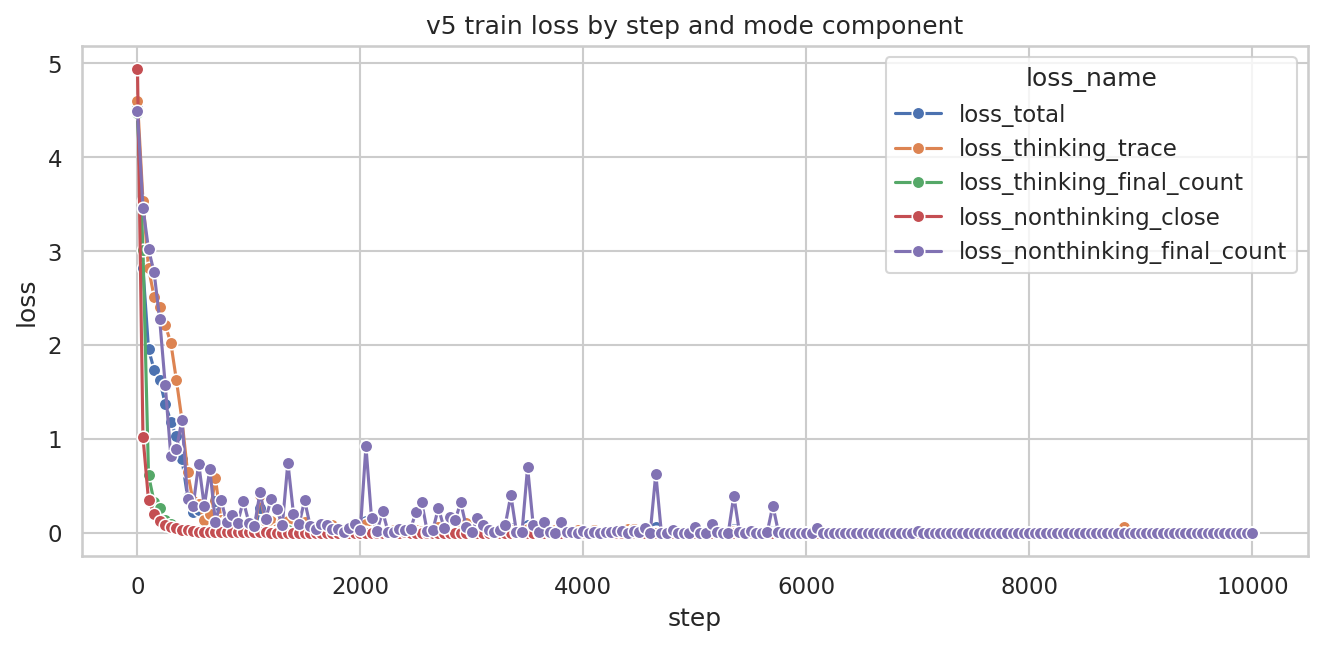

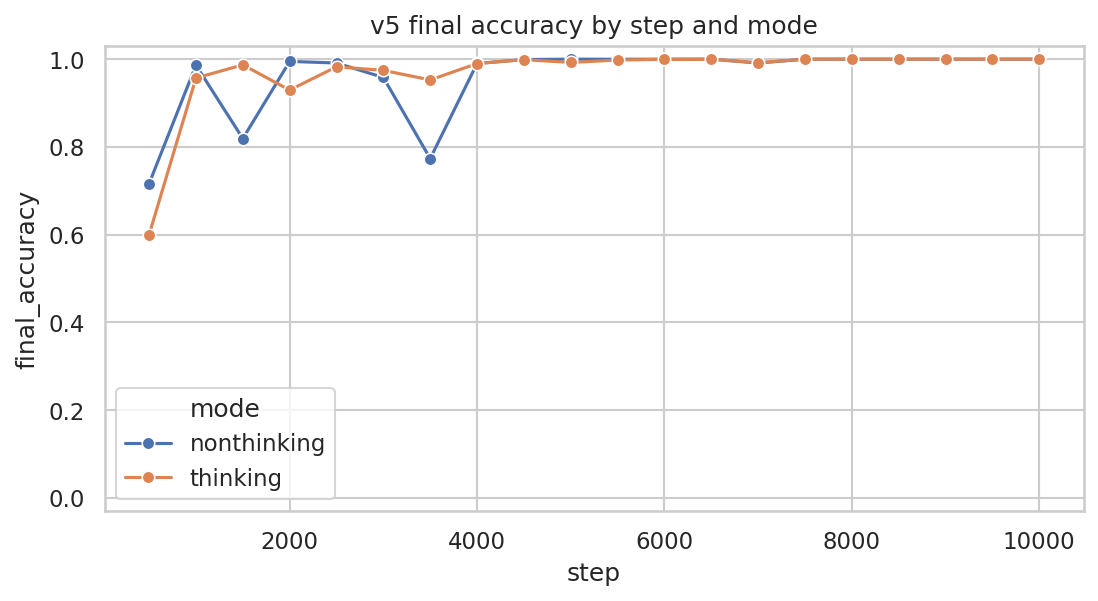

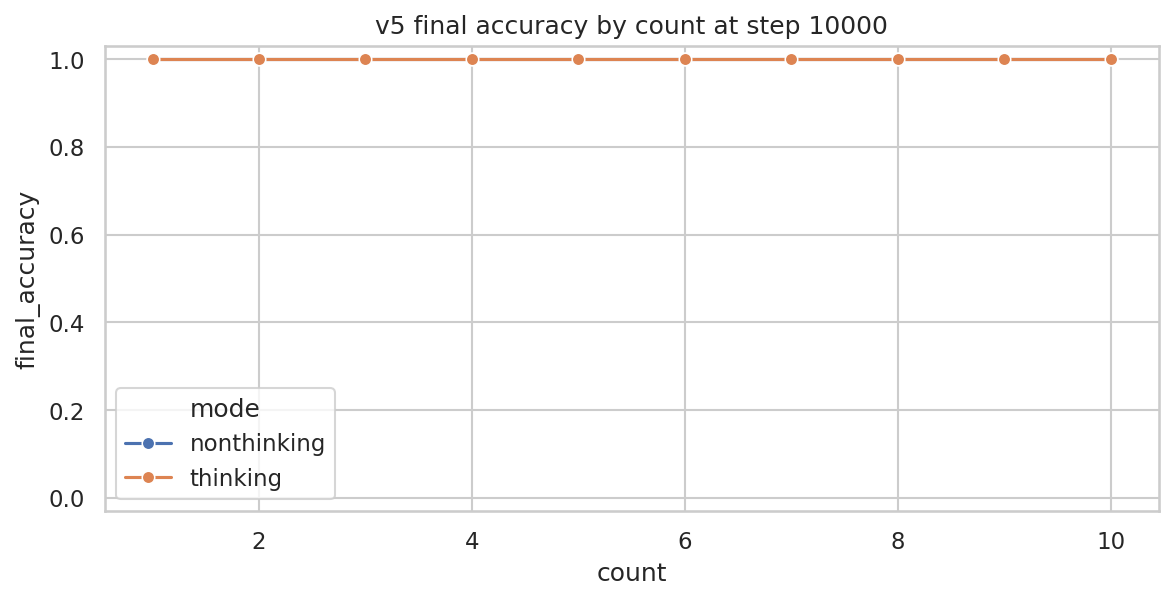

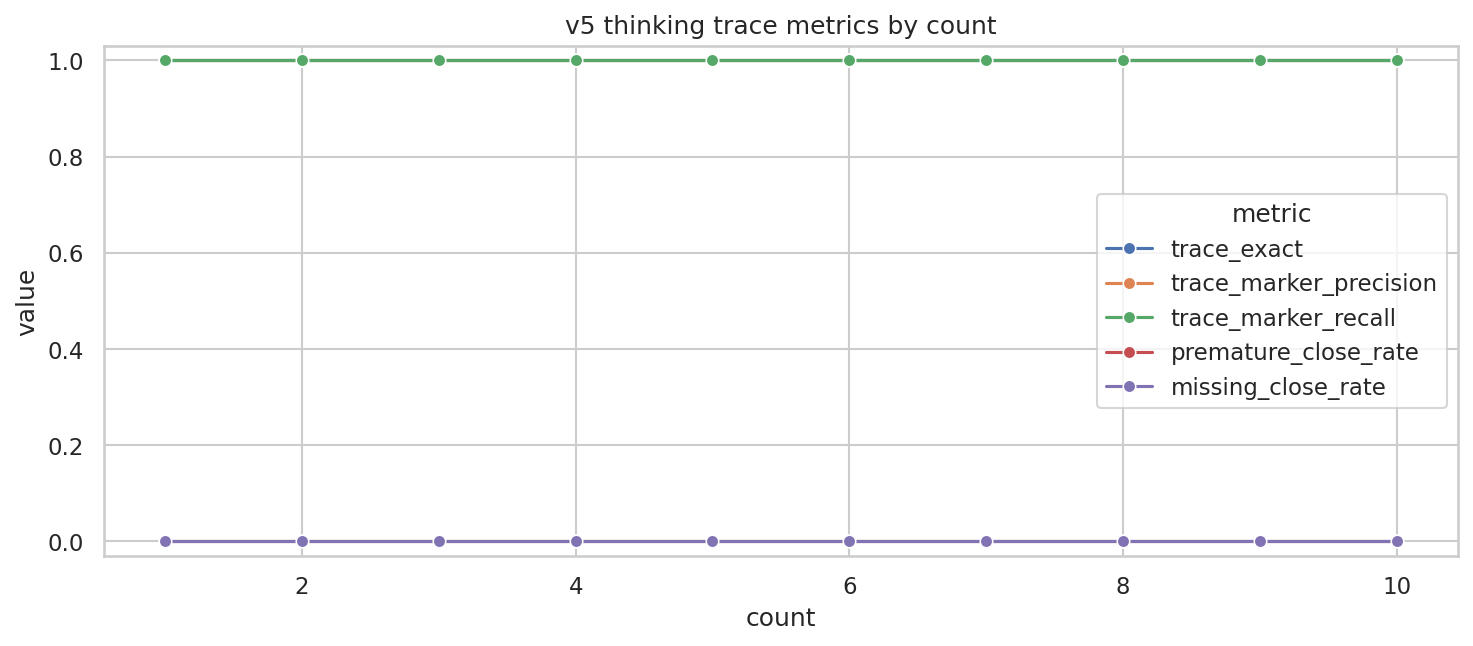

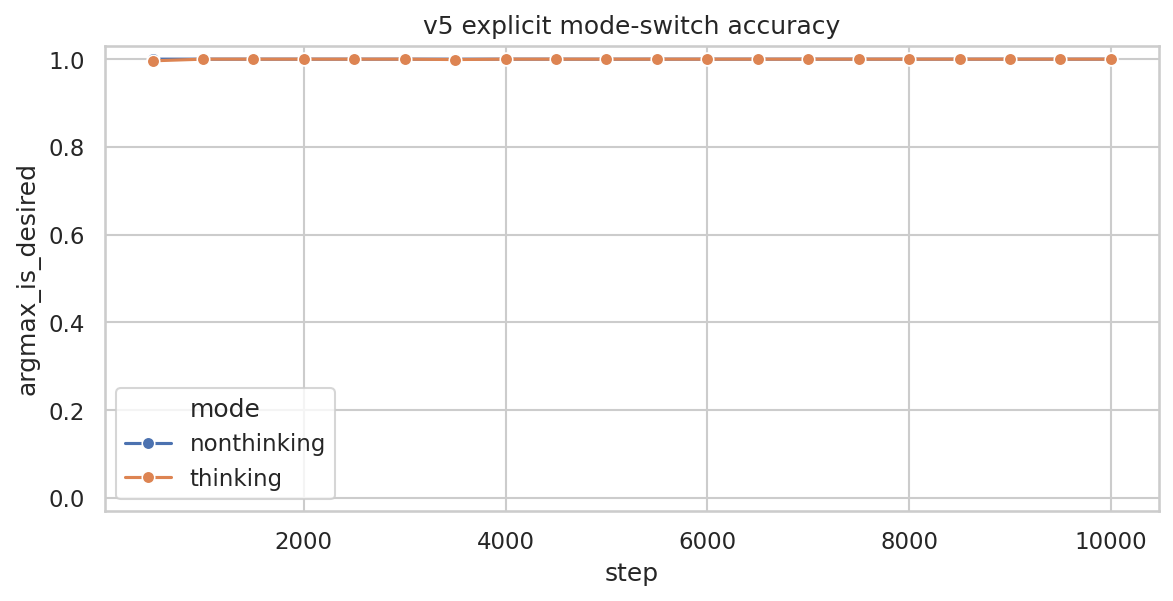

In [6]:
from IPython.display import Image, display

for name in [
    'train_loss_by_step_and_mode.png',
    'final_accuracy_by_step_mode.png',
    'final_accuracy_by_count_mode.png',
    'trace_metrics_by_count.png',
    'mode_switch_accuracy_by_step.png',
]:
    path = RUN_DIR / 'figures' / name
    if path.exists():
        display(Image(filename=str(path)))

## Save to Google Drive

In [7]:
DRIVE_SAVE_COMPLETED = True
if 'google.colab' in sys.modules:
    from google.colab import drive
    ensure_google_drive_mounted()
    drive_dir = pathlib.Path('/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results')
    drive_dir.mkdir(parents=True, exist_ok=True)
    subprocess.check_call(['bash', '-lc', f'cp -r {RUN_DIR} {drive_dir}/'])
    DRIVE_SAVE_COMPLETED = True
    print('Saved to', drive_dir)
else:
    print('Not in Colab; skipping Google Drive save.')

Google Drive ready: /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results
Saved to /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results


## Auto-disconnect Colab Runtime

This cell runs immediately after the Google Drive save cell. It only disconnects when a Drive save was confirmed; local VSCode/Jupyter runs are not force-closed by default.

In [8]:
AUTO_DISCONNECT_AFTER_DRIVE_SAVE = True
FORCE_LOCAL_KERNEL_SHUTDOWN = False

if AUTO_DISCONNECT_AFTER_DRIVE_SAVE and globals().get("DRIVE_SAVE_COMPLETED", False):
    import time

    print("Google Drive save completed. Flushing Drive and disconnecting Colab runtime in 3 seconds...")
    time.sleep(3)
    try:
        from google.colab import drive, runtime

        try:
            drive.flush_and_unmount()
            print("Google Drive flushed and unmounted.")
        except Exception as e:
            print(f"Drive flush/unmount skipped or failed: {e}")
        runtime.unassign()
    except Exception as e:
        print(f"Colab runtime disconnect unavailable or failed: {e}")
        if FORCE_LOCAL_KERNEL_SHUTDOWN:
            import IPython

            IPython.Application.instance().kernel.do_shutdown(restart=False)
        else:
            print("Not forcing local kernel shutdown.")
else:
    print("Auto-disconnect skipped: no confirmed Google Drive save, or AUTO_DISCONNECT_AFTER_DRIVE_SAVE is False.")

Google Drive save completed. Flushing Drive and disconnecting Colab runtime in 3 seconds...
Google Drive flushed and unmounted.


## Optional GitHub Save

In [9]:
COMMIT_RESULTS = False
if COMMIT_RESULTS:
    subprocess.check_call(['git', 'status', '--short'])
    subprocess.check_call(['git', 'add', str(RUN_DIR)])
    subprocess.check_call(['git', 'commit', '-m', f'Add synthetic NIAH v5 {PRESET} results'])
    subprocess.check_call(['git', 'push'])